Notebook para a geração do gráfico de comparação das curvas de tempo de execução 

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv('out.csv', encoding='utf-16')
df

,n_players,func,t_exec
0,100000,insert,9.382500e+01
1,100000,merge,1.424360e-01
2,66666,insert,4.102490e+01
3,66666,merge,9.505220e-02
4,44444,insert,1.866130e+01
...,...,...,...
555,3,merge,1.400000e-06
556,2,insert,3.000000e-07
557,2,merge,1.100000e-06
558,1,insert,2.000000e-07


In [52]:
gdf = df.groupby(by=['func', 'n_players']).mean()
gdf

t_exec
func   n_players              
insert 1          2.600000e-07
       2          2.700000e-07
       3          3.900000e-07
       5          5.300000e-07
       8          9.000000e-07
       12         1.580000e-06
       19         3.660000e-06
       29         8.440000e-06
       44         1.818000e-05
       67         3.830000e-05
       101        8.495000e-05
       152        2.032700e-04
       228        5.079100e-04
       342        1.070600e-03
       513        2.379290e-03
       770        5.450410e-03
       1155       1.176612e-02
       1733       2.924079e-02
       2600       6.787569e-02
       3901       1.542509e-01
       5852       3.404951e-01
       8778       7.772894e-01
       13168      1.733554e+00
       19752      4.042454e+00
       29629      9.024882e+00
       44444      2.008402e+01
       66666      4.735770e+01
       100000     1.047660e+02
merge  1          1.700000e-07
       2          1.460000e-06
       3          2.170000e-06
       5          3.580000e-06
       8          4.910000e-06
       12         7.610000e-06
       19         1.372000e-05
       29         2.164000e-05
       44         3.500000e-05
       67         5.324000e-05
       101        7.358000e-05
       152        1.201800e-04
       228        1.801600e-04
       342        2.985900e-04
       513        4.562900e-04
       770        7.254100e-04
       1155       1.103600e-03
       1733       1.809750e-03
       2600       2.768540e-03
       3901       4.111000e-03
       5852       6.580270e-03
       8778       1.066764e-02
       13168      1.604085e-02
       19752      2.595305e-02
       29629      3.848814e-02
       44444      6.041389e-02
       66666      9.584324e-02
       100000     1.547178e-01

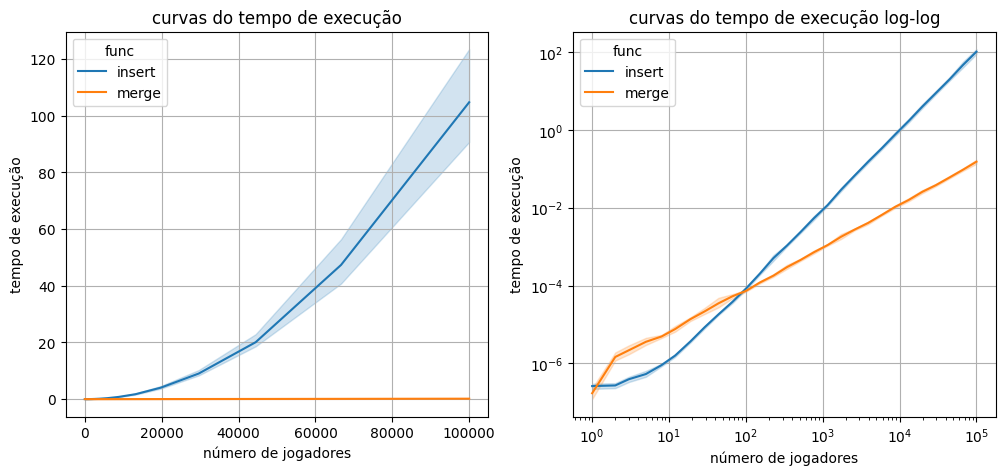

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(df, x='n_players', y='t_exec', hue='func', ax = axs[0])
sns.lineplot(df, x='n_players', y='t_exec', hue='func', ax = axs[1])
    
axs[0].set_title('curvas do tempo de execução')
axs[1].set_title('curvas do tempo de execução log-log')
axs[1].set_yscale('log')
axs[1].set_xscale('log')

for ax in axs:
    ax.set_ylabel('tempo de execução')
    ax.set_xlabel('número de jogadores')
    ax.grid(True)

C:\Users\rudab\AppData\Local\Temp\ipykernel_10596\2913386692.py:10: RuntimeWarning: divide by zero encountered in log2
  sns.lineplot(x=ns, y=ns*np.log2(ns)*1e-7, ax=axs[1], label='O(n log(n))')
C:\Users\rudab\AppData\Local\Temp\ipykernel_10596\2913386692.py:10: RuntimeWarning: invalid value encountered in multiply
  sns.lineplot(x=ns, y=ns*np.log2(ns)*1e-7, ax=axs[1], label='O(n log(n))')


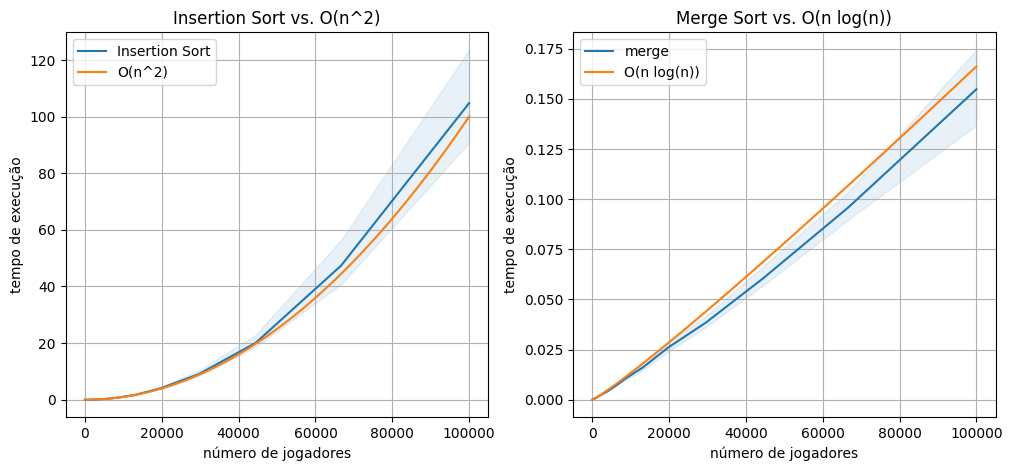

In [57]:
max_players = df.iloc[df['n_players'].idxmax()]['n_players']
ns = np.arange(max_players)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(df[df['func'] == 'insert'], x='n_players', y='t_exec', ax = axs[0], label='Insertion Sort', err_kws={'alpha': 0.1})
sns.lineplot(x=ns, y=ns**2*1e-8, label='O(n^2)', ax=axs[0])

sns.lineplot(df[df['func'] == 'merge'], x='n_players', y='t_exec', hue='func', ax = axs[1], err_kws={'alpha': 0.1})
sns.lineplot(x=ns, y=ns*np.log2(ns)*1e-7, ax=axs[1], label='O(n log(n))')
    
axs[0].set_title('Insertion Sort vs. O(n^2)')
axs[1].set_title('Merge Sort vs. O(n log(n))')

for ax in axs:
    ax.set_ylabel('tempo de execução')
    ax.set_xlabel('número de jogadores')
    ax.grid(True)